# Feature Selection FPT

In [1]:
stock_code = "FPT"

In [2]:
stock_code = str.lower(stock_code)

## Import libraries

In [3]:
import os
import sys
import pandas as pd

# go one level up from where the notebook is running
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger
from feature_selector.feature_selector import (
    FeatureSelector,
)
from utils.constants import *
from utils.enums import *
from utils.utils import cast_columns_to_float
from dtos.tabular_database_driver_dtos.tabular_database_driver_dtos import *
from tabular_database_driver.postgre_sql_driver import PostgreSQLDriver
from dtos.tabular_database_driver_dtos.postgre_sql_connection_dto import (
    PostgreSQLConnectionDto,
)
from matplotlib.pylab import ceil

## Initialize the Logger

In [4]:
my_logger = Logger(
    file_name=f"{FEATURE_SELECTION_LOG_FILE_BASE}/{stock_code}_feature_selection"
)

## List all FeatureSelectorType

In [5]:
print([member.name for member in FeatureSelectorType])

['XGB_REGRESSOR', 'LASSO', 'ELASTIC_NET', 'XGB_SHAP']


## Initialize the Database Driver

In [6]:
database_driver = PostgreSQLDriver(logger=my_logger)

connection_model = PostgreSQLConnectionDto(
    logger=my_logger,
    host=os.getenv("POSTGRES_HOST"),
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD"),
    port=os.getenv("POSTGRES_PORT"),
    database=os.getenv("GOLD_POSTGRES_DATABASE"),
)

database_driver.connect(connection_model)

<DatabaseExecutionStatus.SUCCESS: 'success'>

## Parameters

In [7]:
output_column_name = "close"

In [8]:
train_ratio = DEFAULT_TRAIN_RATIO
train_window_size = DEFAULT_TRAIN_WINDOW_SIZE
validation_window_size = DEFAULT_VALIDATION_WINDOW_SIZE
test_window_size = DEFAULT_TEST_WINDOW_SIZE

## Load data

In [9]:
df = database_driver.select(
    schema_name=Schema.ENTERPRISE.value,
    table_name=f"unified_{stock_code}",
)
df = cast_columns_to_float(df)

In [10]:
df

,date,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,...,is_quarter_end,week_of_month,half_of_year,season,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,2006-12-13,7.552055,14.203619,2888.656452,92.003231,253.595161,16.025534,22.747446,11.056317,474.899933,...,0.0,2.0,2.0,1.0,-2.449294e-16,1.000000,0.974928,-0.222521,-0.304921,0.952378
1,2006-12-14,7.553425,14.216089,2898.413871,92.084006,265.067097,16.039604,22.767417,11.066024,475.316878,...,0.0,2.0,2.0,1.0,-2.449294e-16,1.000000,0.433884,-0.900969,-0.288482,0.957485
2,2006-12-15,7.554795,14.228559,2908.171290,92.164782,276.539032,16.053674,22.787388,11.075731,475.733823,...,0.0,3.0,2.0,1.0,-2.449294e-16,1.000000,-0.433884,-0.900969,-0.271958,0.962309
3,2024-06-25,6.860220,94.063122,805.000000,533.333333,65.833333,144.166667,218.333333,214.166667,2441.666667,...,0.0,4.0,1.0,3.0,1.224647e-16,-1.000000,0.781831,0.623490,0.094537,-0.995521
4,2006-12-18,7.558904,14.265970,2937.443548,92.407108,310.954839,16.095883,22.847303,11.104852,476.984656,...,0.0,3.0,2.0,1.0,-2.449294e-16,1.000000,0.000000,1.000000,-0.221922,0.975065
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4610,2025-01-14,7.453556,85.816129,828.761290,576.737742,47.004839,285.945161,238.564194,230.051290,2151.579677,...,0.0,2.0,1.0,1.0,5.000000e-01,0.866025,0.781831,0.623490,0.238673,0.971100
4611,2025-01-20,7.412222,81.271613,809.416129,576.226774,43.865484,280.564516,234.987419,226.486129,2102.520968,...,0.0,3.0,1.0,1.0,5.000000e-01,0.866025,0.000000,1.000000,0.337523,0.941317
4612,2025-01-21,7.405333,80.514194,806.191935,576.141613,43.342258,279.667742,234.391290,225.891935,2094.344516,...,0.0,3.0,1.0,1.0,5.000000e-01,0.866025,0.781831,0.623490,0.353676,0.935368
4613,2025-01-22,7.398444,79.756774,802.967742,576.056452,42.819032,278.770968,233.795161,225.297742,2086.168065,...,0.0,4.0,1.0,1.0,5.000000e-01,0.866025,0.974928,-0.222521,0.369725,0.929141


In [11]:
def _find_split_index(
    dataframe: pd.DataFrame,
    train_window_size: int,
    validation_window_size: int,
    test_window_size: int,
    train_ratio: float,
) -> int:
    """
    Determine the index to split the dataframe into training and testing portions
    for time series forecasting with explicit validation and test windows.

    Rules:
    1. Split based on `train_ratio`.
    2. Ensure there's enough data left for both validation and test windows.
    3. Ensure the split index aligns cleanly with test window size for consistency.
    """

    # --- Sort chronologically if 'date' column exists ---
    if "date" in dataframe.columns:
        dataframe = dataframe.sort_values("date").reset_index(drop=True)
    else:
        dataframe = dataframe.reset_index(drop=True)

    total_len = len(dataframe)
    min_required = train_window_size + validation_window_size + test_window_size

    if total_len <= min_required:
        raise ValueError(
            f"Data length ({total_len}) must exceed total required window size "
            f"({min_required})."
        )

    # --- Initial rough split ---
    split_index = ceil(total_len * train_ratio)

    # --- Adjust to ensure validation & test windows fit after split ---
    split_index = min(
        split_index, total_len - (validation_window_size + test_window_size)
    )

    # --- Align to multiple of test_window_size (optional smoothing) ---
    remainder = split_index % test_window_size
    if remainder != 0:
        split_index -= remainder

    # --- Guard against invalid split ---
    if split_index <= train_window_size or split_index >= total_len:
        raise ValueError(
            f"Adjusted split_index ({split_index}) invalid for data length {total_len}"
        )

    return int(split_index)


split_index = _find_split_index(
    dataframe=df,
    train_window_size=train_window_size,
    validation_window_size=validation_window_size,
    test_window_size=test_window_size,
    train_ratio=train_ratio,
)

split_index

4140

In [12]:
# --- Split train/test ---
train = df.iloc[:split_index].reset_index(drop=True)
test = df.iloc[split_index:].reset_index(drop=True)

In [13]:
train

,date,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,...,is_quarter_end,week_of_month,half_of_year,season,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,2006-12-13,7.552055,14.203619,2888.656452,92.003231,253.595161,16.025534,22.747446,11.056317,474.899933,...,0.0,2.0,2.0,1.0,-2.449294e-16,1.000000,0.974928,-0.222521,-0.304921,0.952378
1,2006-12-14,7.553425,14.216089,2898.413871,92.084006,265.067097,16.039604,22.767417,11.066024,475.316878,...,0.0,2.0,2.0,1.0,-2.449294e-16,1.000000,0.433884,-0.900969,-0.288482,0.957485
2,2006-12-15,7.554795,14.228559,2908.171290,92.164782,276.539032,16.053674,22.787388,11.075731,475.733823,...,0.0,3.0,2.0,1.0,-2.449294e-16,1.000000,-0.433884,-0.900969,-0.271958,0.962309
3,2024-06-25,6.860220,94.063122,805.000000,533.333333,65.833333,144.166667,218.333333,214.166667,2441.666667,...,0.0,4.0,1.0,3.0,1.224647e-16,-1.000000,0.781831,0.623490,0.094537,-0.995521
4,2006-12-18,7.558904,14.265970,2937.443548,92.407108,310.954839,16.095883,22.847303,11.104852,476.984656,...,0.0,3.0,2.0,1.0,-2.449294e-16,1.000000,0.000000,1.000000,-0.221922,0.975065
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4135,2022-07-11,8.431413,85.146891,996.774194,388.064516,48.225806,296.774194,214.516129,325.806452,1612.903226,...,0.0,2.0,2.0,3.0,-5.000000e-01,-0.866025,0.000000,1.000000,-0.162807,-0.986658
4136,2022-07-12,8.496087,85.159361,991.935484,385.161290,48.064516,291.935484,216.290323,324.516129,1632.258065,...,0.0,2.0,2.0,3.0,-5.000000e-01,-0.866025,0.781831,0.623490,-0.179767,-0.983709
4137,2022-07-13,8.560761,85.171831,987.096774,382.258065,47.903226,287.096774,218.064516,323.225806,1651.612903,...,0.0,2.0,2.0,3.0,-5.000000e-01,-0.866025,0.974928,-0.222521,-0.196673,-0.980469
4138,2022-07-14,8.625435,85.184302,982.258065,379.354839,47.741935,282.258065,219.838710,321.935484,1670.967742,...,0.0,2.0,2.0,3.0,-5.000000e-01,-0.866025,0.433884,-0.900969,-0.213521,-0.976938


In [14]:
test

,date,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,...,is_quarter_end,week_of_month,half_of_year,season,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,2022-07-18,8.884130,85.234183,962.903226,367.741935,47.096774,262.903226,226.935484,316.774194,1748.387097,...,0.0,3.0,2.0,3.0,-0.5,-0.866025,0.000000,1.000000,-0.280231,-0.959933
1,2022-07-19,8.948804,85.246653,958.064516,364.838710,46.935484,258.064516,228.709677,315.483871,1767.741935,...,0.0,3.0,2.0,3.0,-0.5,-0.866025,0.781831,0.623490,-0.296713,-0.954967
2,2022-07-20,9.013478,85.259123,953.225806,361.935484,46.774194,253.225806,230.483871,314.193548,1787.096774,...,0.0,3.0,2.0,3.0,-0.5,-0.866025,0.974928,-0.222521,-0.313107,-0.949718
3,2022-07-21,9.078152,85.271593,948.387097,359.032258,46.612903,248.387097,232.258065,312.903226,1806.451613,...,0.0,3.0,2.0,3.0,-0.5,-0.866025,0.433884,-0.900969,-0.329408,-0.944188
4,2022-07-22,9.142826,85.284064,943.548387,356.129032,46.451613,243.548387,234.032258,311.612903,1825.806452,...,0.0,4.0,2.0,3.0,-0.5,-0.866025,-0.433884,-0.900969,-0.345612,-0.938377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
470,2025-01-14,7.453556,85.816129,828.761290,576.737742,47.004839,285.945161,238.564194,230.051290,2151.579677,...,0.0,2.0,1.0,1.0,0.5,0.866025,0.781831,0.623490,0.238673,0.971100
471,2025-01-20,7.412222,81.271613,809.416129,576.226774,43.865484,280.564516,234.987419,226.486129,2102.520968,...,0.0,3.0,1.0,1.0,0.5,0.866025,0.000000,1.000000,0.337523,0.941317
472,2025-01-21,7.405333,80.514194,806.191935,576.141613,43.342258,279.667742,234.391290,225.891935,2094.344516,...,0.0,3.0,1.0,1.0,0.5,0.866025,0.781831,0.623490,0.353676,0.935368
473,2025-01-22,7.398444,79.756774,802.967742,576.056452,42.819032,278.770968,233.795161,225.297742,2086.168065,...,0.0,4.0,1.0,1.0,0.5,0.866025,0.974928,-0.222521,0.369725,0.929141


In [15]:
train = train.drop(columns=["date"])

In [16]:
train

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,is_quarter_end,week_of_month,half_of_year,season,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,7.552055,14.203619,2888.656452,92.003231,253.595161,16.025534,22.747446,11.056317,474.899933,747.464516,...,0.0,2.0,2.0,1.0,-2.449294e-16,1.000000,0.974928,-0.222521,-0.304921,0.952378
1,7.553425,14.216089,2898.413871,92.084006,265.067097,16.039604,22.767417,11.066024,475.316878,750.208710,...,0.0,2.0,2.0,1.0,-2.449294e-16,1.000000,0.433884,-0.900969,-0.288482,0.957485
2,7.554795,14.228559,2908.171290,92.164782,276.539032,16.053674,22.787388,11.075731,475.733823,752.952903,...,0.0,3.0,2.0,1.0,-2.449294e-16,1.000000,-0.433884,-0.900969,-0.271958,0.962309
3,6.860220,94.063122,805.000000,533.333333,65.833333,144.166667,218.333333,214.166667,2441.666667,86.666667,...,0.0,4.0,1.0,3.0,1.224647e-16,-1.000000,0.781831,0.623490,0.094537,-0.995521
4,7.558904,14.265970,2937.443548,92.407108,310.954839,16.095883,22.847303,11.104852,476.984656,761.185484,...,0.0,3.0,2.0,1.0,-2.449294e-16,1.000000,0.000000,1.000000,-0.221922,0.975065
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4135,8.431413,85.146891,996.774194,388.064516,48.225806,296.774194,214.516129,325.806452,1612.903226,137.903226,...,0.0,2.0,2.0,3.0,-5.000000e-01,-0.866025,0.000000,1.000000,-0.162807,-0.986658
4136,8.496087,85.159361,991.935484,385.161290,48.064516,291.935484,216.290323,324.516129,1632.258065,137.258065,...,0.0,2.0,2.0,3.0,-5.000000e-01,-0.866025,0.781831,0.623490,-0.179767,-0.983709
4137,8.560761,85.171831,987.096774,382.258065,47.903226,287.096774,218.064516,323.225806,1651.612903,136.612903,...,0.0,2.0,2.0,3.0,-5.000000e-01,-0.866025,0.974928,-0.222521,-0.196673,-0.980469
4138,8.625435,85.184302,982.258065,379.354839,47.741935,282.258065,219.838710,321.935484,1670.967742,135.967742,...,0.0,2.0,2.0,3.0,-5.000000e-01,-0.866025,0.433884,-0.900969,-0.213521,-0.976938


## Feature Selection

In [17]:
feature_columns = train.columns.tolist()
feature_columns.remove(output_column_name)
len(feature_columns)

201

In [18]:
my_feature_selector = FeatureSelector(
    logger=my_logger,
    stock_code=stock_code,
    dataframe=train,
    feature_columns=feature_columns,
    target_column=output_column_name,
)

## Feature Selection Fit

In [19]:
my_feature_selector.fit()

Feature Selector Types:
['XGB_REGRESSOR', 'LASSO', 'ELASTIC_NET', 'XGB_SHAP']

Fitting feature selectors...

Fitting XGB feature selector...
Done fitting XGB feature selector...
Fitting LASSO feature selector...


d:\GIT\master-thesis\mt_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.628e+02, tolerance: 2.504e+02
  model = cd_fast.enet_coordinate_descent(


Done fitting LASSO feature selector...
Fitting ELASTC NET feature selector...


d:\GIT\master-thesis\mt_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.821e+02, tolerance: 2.504e+02
  model = cd_fast.enet_coordinate_descent(


Done fitting ELASTC NET feature selector...
Fitting XGB SHAP feature selector...
Done fitting XGB SHAP feature selector...

Done fitting feature selectors...


## Feature Selection Type: XGB_REGRESSOR

In [20]:
my_feature_selector.get_feature_importance(FeatureSelectorType.XGB_REGRESSOR)

,feature,importance
0,mip_fabric,1.000000
1,labor_urban_unemployment_rate,0.635510
2,population_population,0.390448
3,labor_unemployed,0.207357
4,labor_labor_force_participation_rate_percent,0.169624
...,...,...
196,mip_gravel_and_pebbles,0.000000
197,mip_household_refrigerators_and_freezers,0.000000
198,nyse_composite_adj_close,0.000000
199,mip_light_bulbs,0.000000


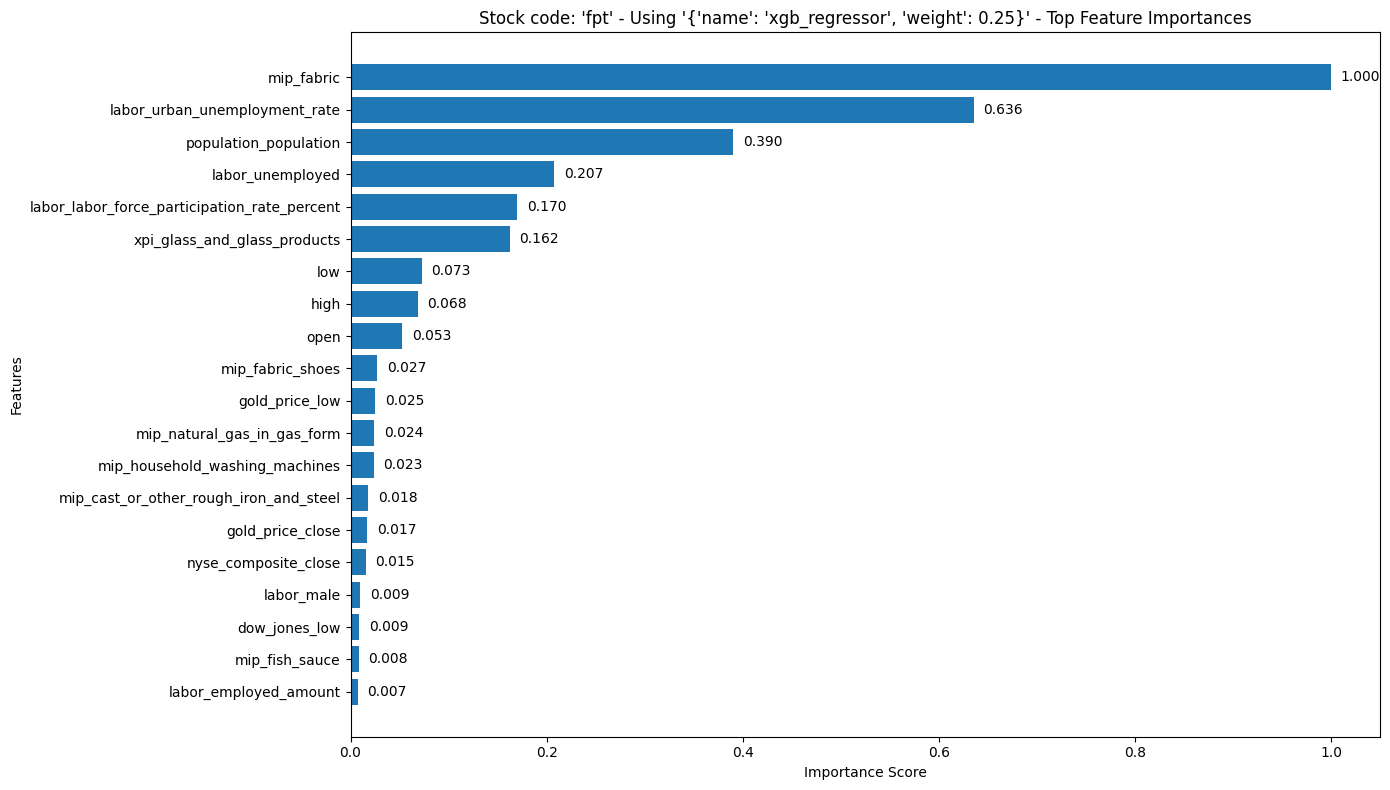

In [21]:
my_feature_selector.plot_feature_importance(FeatureSelectorType.XGB_REGRESSOR)

## Feature Selection Type: LASSO

In [22]:
my_feature_selector.get_feature_importance(FeatureSelectorType.LASSO)

,feature,importance
0,open,1.000000
1,high,0.207677
2,ipv_rolled_steel,0.003079
3,mip_standard_batteries_15v,0.001655
4,nasdaq_composite_volume,0.000274
...,...,...
196,mip_assembled_motorcycles_and_mopeds,0.000000
197,mip_assembled_tvs,0.000000
198,mip_beer,0.000000
199,mip_canned_fruits_and_nuts,0.000000


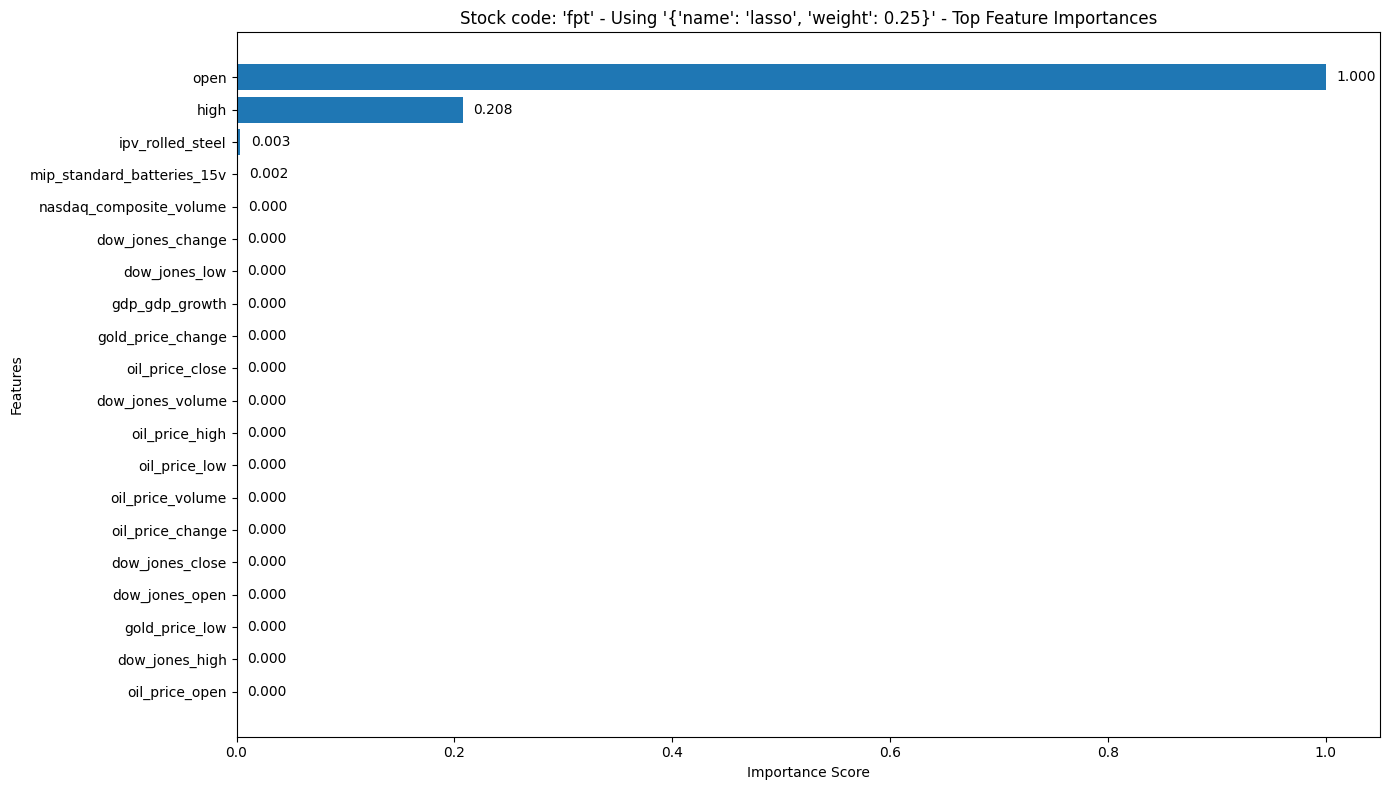

In [23]:
my_feature_selector.plot_feature_importance(FeatureSelectorType.LASSO)

## Feature Selection Type: ELASTIC_NET

In [24]:
my_feature_selector.get_feature_importance(FeatureSelectorType.ELASTIC_NET)

,feature,importance
0,low,1.000000
1,high,0.986661
2,open,0.978732
3,labor_labor_force_annual_change_percent,0.169529
4,mip_assembled_motorcycles_and_mopeds,0.132693
...,...,...
196,mip_crude_oil_extraction,0.000000
197,mip_fabric,0.000000
198,mip_fabric_shoes,0.000000
199,mip_fiber,0.000000


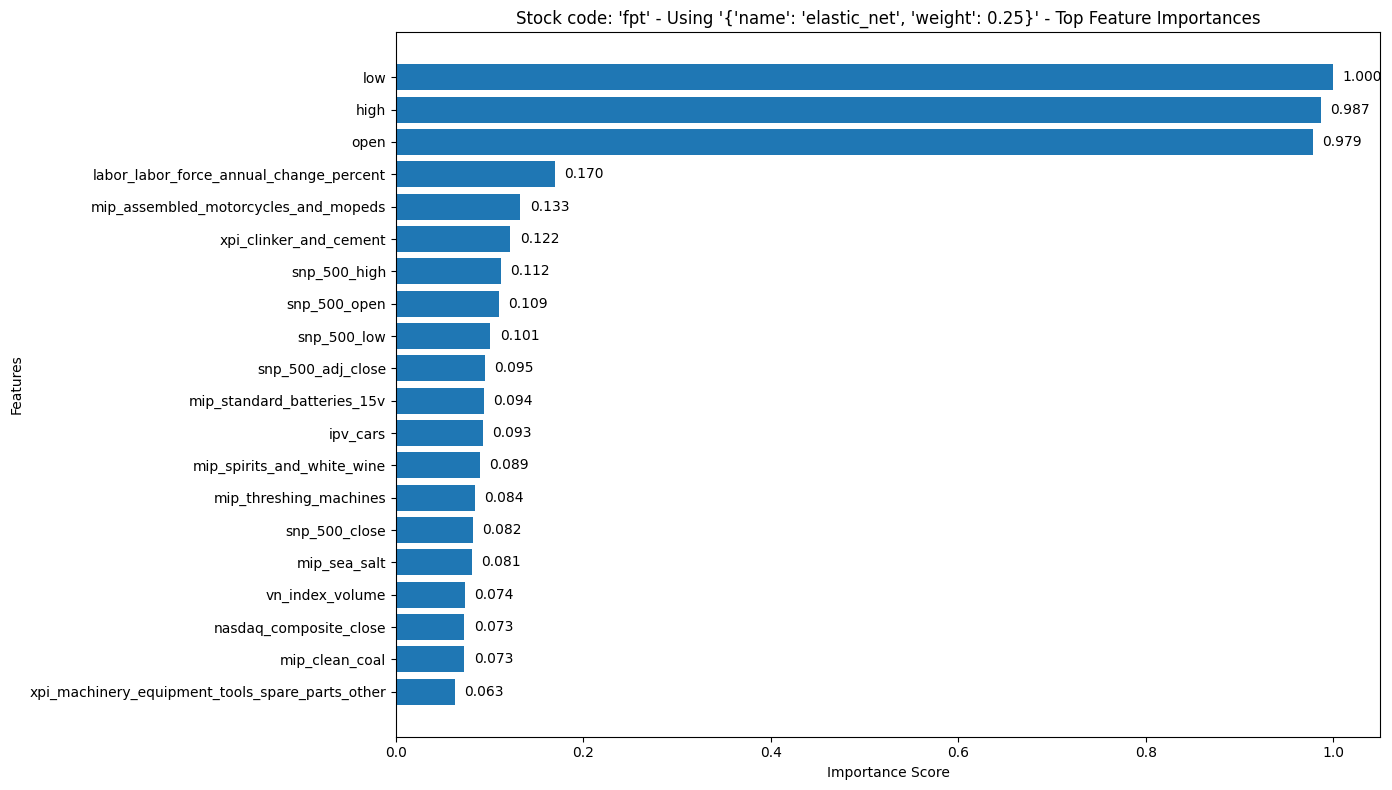

In [25]:
my_feature_selector.plot_feature_importance(FeatureSelectorType.ELASTIC_NET)

## Feature Selection Type: XGB_SHAP

In [26]:
my_feature_selector.get_feature_importance(FeatureSelectorType.XGB_SHAP)

,feature,importance
0,high,1.000000
1,low,0.871100
2,mip_fabric,0.297127
3,population_population,0.209375
4,xpi_glass_and_glass_products,0.188555
...,...,...
196,mip_pesticides,0.000000
197,mip_paper_and_cardboard,0.000000
198,mip_mineral_water,0.000000
199,mip_light_bulbs,0.000000


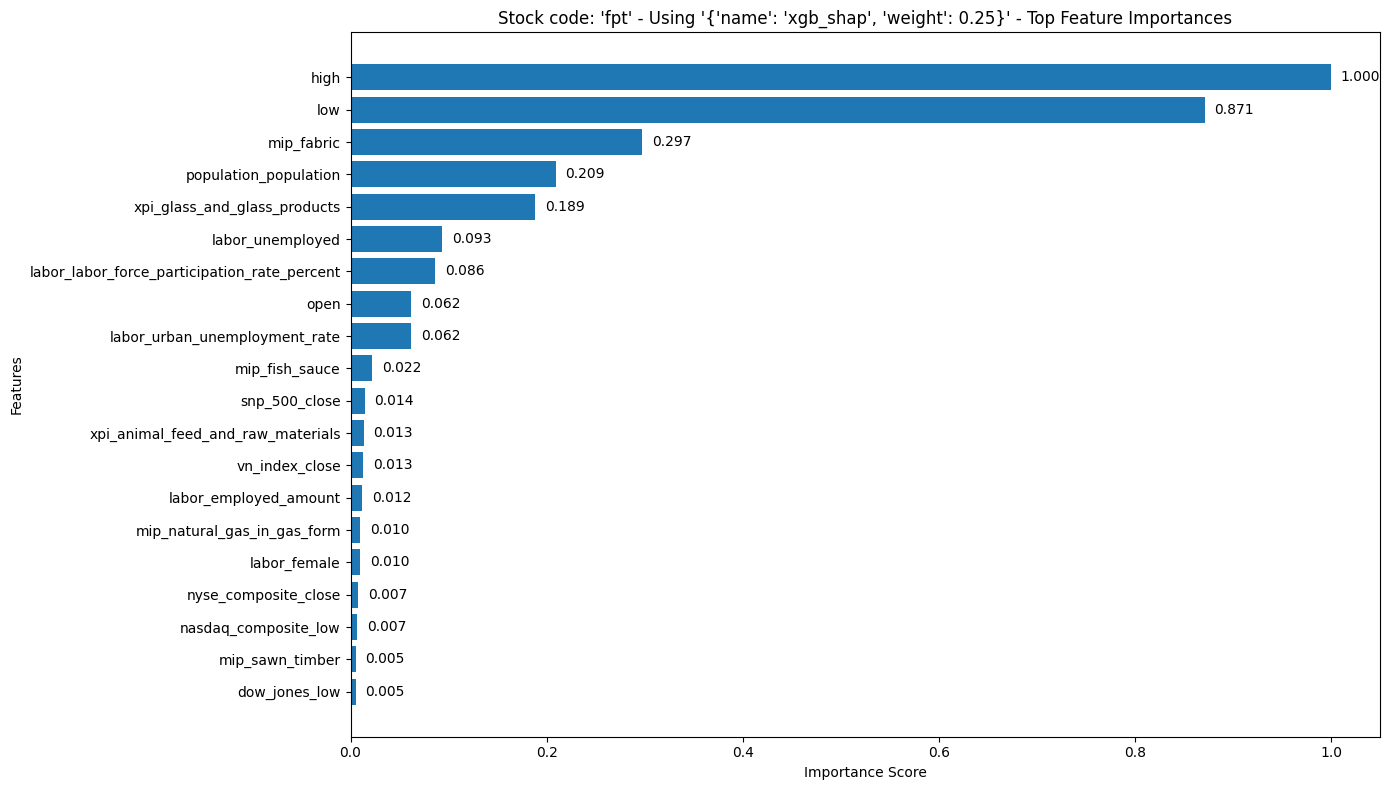

In [27]:
my_feature_selector.plot_feature_importance(FeatureSelectorType.XGB_SHAP)

## Summrarize Feature Importance

In [28]:
my_feature_selector.get_feature_importance()

,feature,xgb_regressor,lasso,elastic_net,xgb_shap,xgb_regressor_weighted,lasso_weighted,elastic_net_weighted,xgb_shap_weighted,final_importance
0,high,0.068434,0.207677,0.986661,1.000000,0.017109,0.051919,0.246665,0.250000,0.565693
1,open,0.053003,1.000000,0.978732,0.061980,0.013251,0.250000,0.244683,0.015495,0.523429
2,low,0.072590,0.000000,1.000000,0.871100,0.018148,0.000000,0.250000,0.217775,0.485923
3,mip_fabric,1.000000,0.000000,0.000000,0.297127,0.250000,0.000000,0.000000,0.074282,0.324282
4,labor_urban_unemployment_rate,0.635510,0.000000,0.000605,0.061946,0.158877,0.000000,0.000151,0.015486,0.174515
...,...,...,...,...,...,...,...,...,...,...
196,mip_fired_bricks,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
197,mip_fiber_cement_roofing_sheets,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
198,mip_various_types_of_bicycles,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
199,xpi_electrical_wires_and_cables,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


✅ Plot saved to: d:\GIT\master-thesis\logs\feature_selection\fpt_final_feature_importances.png


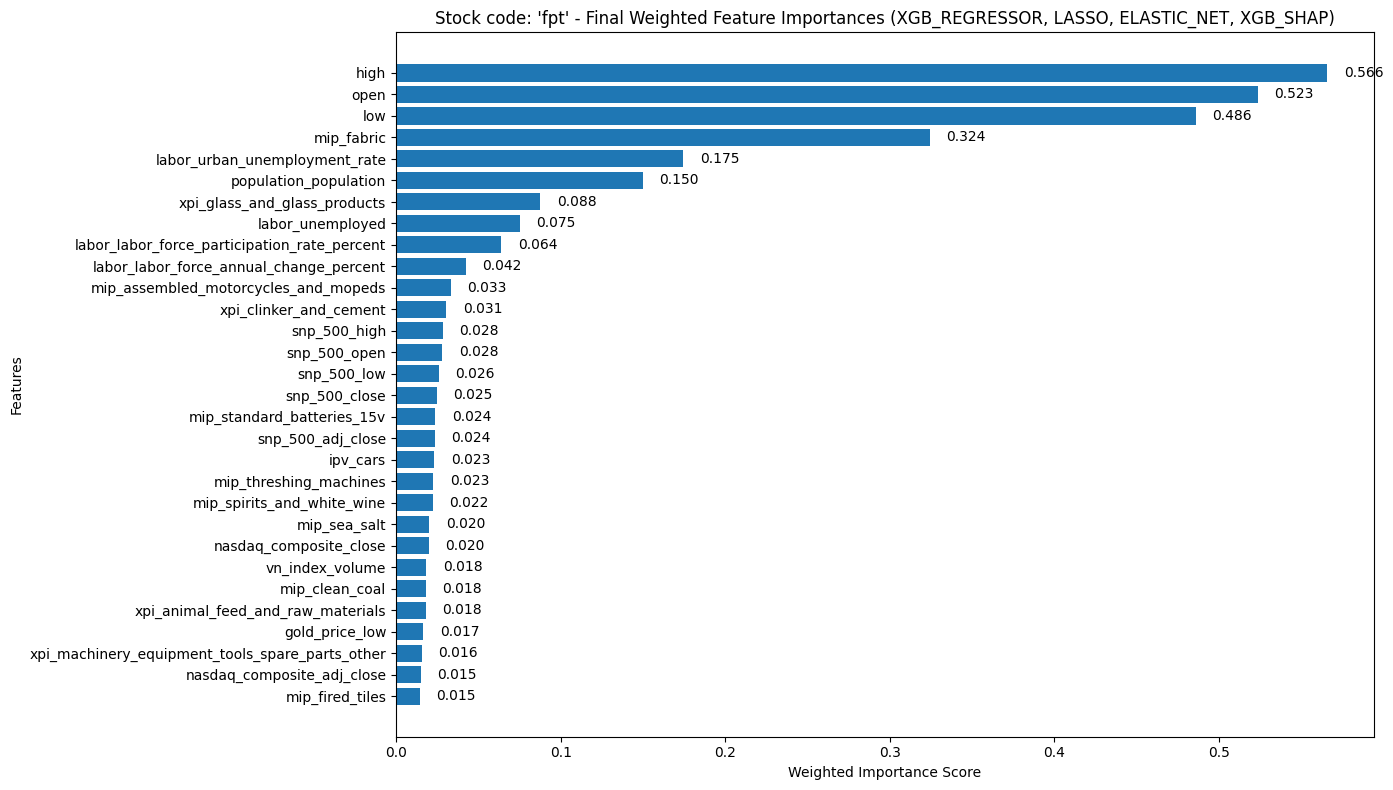

In [29]:
my_feature_selector.plot_final_feature_importances(
    stock_code=stock_code,
    filename=f"{stock_code}_final_feature_importances.png",
    top_n=30,
)

In [30]:
important_features_df = my_feature_selector.get_important_features_df(
    top_n=30,
)

In [31]:
important_features_df

,feature,final_importance
21,high,0.565693
131,open,0.523429
49,low,0.485923
65,mip_fabric,0.324282
48,labor_urban_unemployment_rate,0.174515
132,population_population,0.149956
174,xpi_glass_and_glass_products,0.087688
47,labor_unemployed,0.075195
45,labor_labor_force_participation_rate_percent,0.063965
44,labor_labor_force_annual_change_percent,0.042382


In [32]:
important_features_list = important_features_df["feature"].tolist()
important_features_list

['high',
 'open',
 'low',
 'mip_fabric',
 'labor_urban_unemployment_rate',
 'population_population',
 'xpi_glass_and_glass_products',
 'labor_unemployed',
 'labor_labor_force_participation_rate_percent',
 'labor_labor_force_annual_change_percent',
 'mip_assembled_motorcycles_and_mopeds',
 'xpi_clinker_and_cement',
 'snp_500_high',
 'snp_500_open',
 'snp_500_low',
 'snp_500_close',
 'mip_standard_batteries_15v',
 'snp_500_adj_close',
 'ipv_cars',
 'mip_threshing_machines',
 'mip_spirits_and_white_wine',
 'mip_sea_salt',
 'nasdaq_composite_close',
 'vn_index_volume',
 'mip_clean_coal',
 'xpi_animal_feed_and_raw_materials',
 'gold_price_low',
 'xpi_machinery_equipment_tools_spare_parts_other',
 'nasdaq_composite_adj_close',
 'mip_fired_tiles']

## Heatmap Visualization

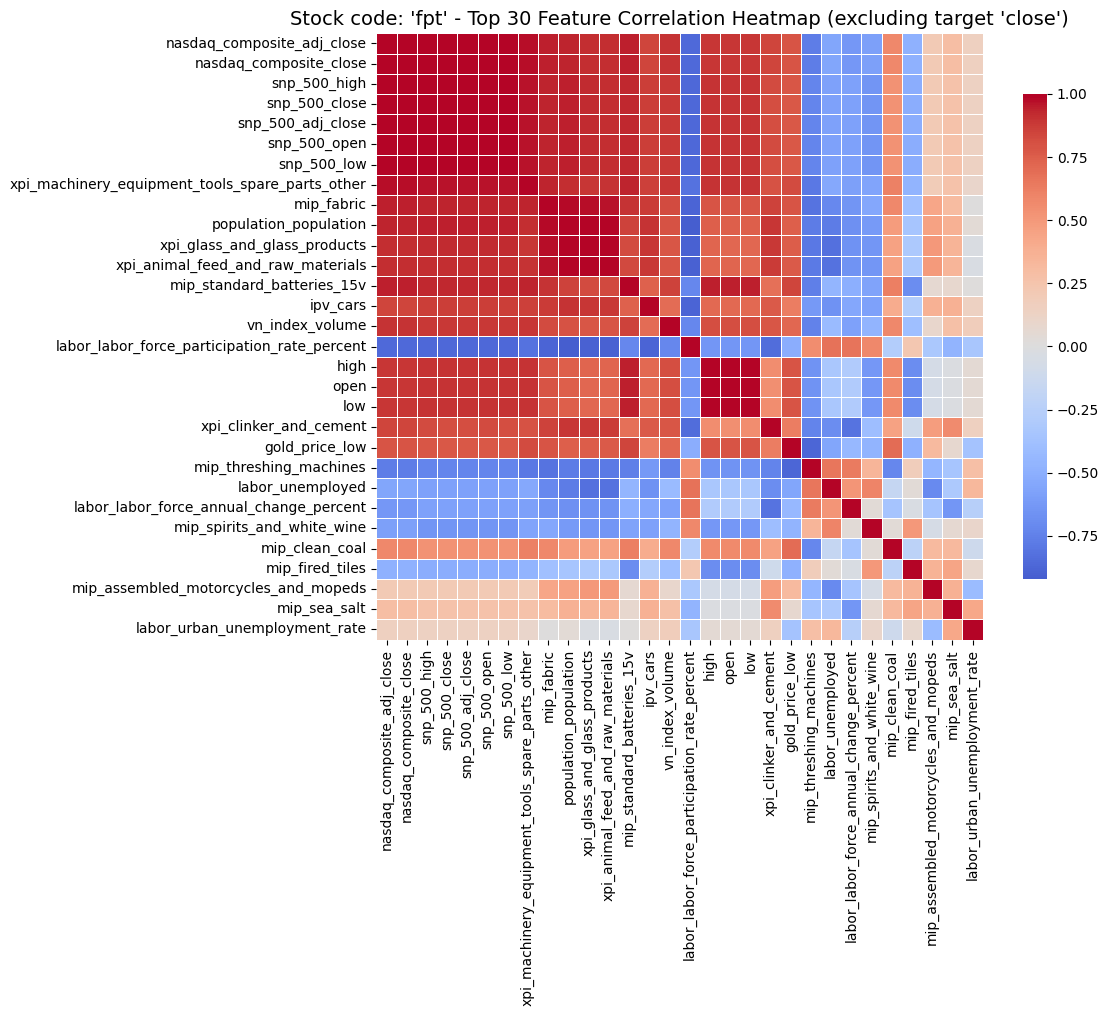

In [33]:
my_feature_selector.plot_feature_correlation_heatmap(
    stock_code=stock_code,
    importane_featrue_list=important_features_list,
    top_corr_threshold=DEFAULT_CORRELATION_THRESHOLD,
)

## Correlation DataFrame

In [34]:
correlation_df = my_feature_selector.get_feature_correlation_df(
    important_features_list=important_features_list,
    top_corr_threshold=DEFAULT_CORRELATION_THRESHOLD,
)

In [35]:
correlation_df

,feature_1,feature_2,corr
0,nasdaq_composite_adj_close,nasdaq_composite_close,1.000000
1,snp_500_close,snp_500_adj_close,1.000000
2,open,low,0.999917
3,snp_500_high,snp_500_open,0.999917
4,snp_500_close,snp_500_low,0.999901
...,...,...,...
137,mip_fabric,labor_labor_force_participation_rate_percent,-0.881996
138,ipv_cars,labor_labor_force_participation_rate_percent,-0.882600
139,xpi_animal_feed_and_raw_materials,labor_labor_force_participation_rate_percent,-0.898738
140,xpi_glass_and_glass_products,labor_labor_force_participation_rate_percent,-0.903752


In [36]:
kept_features, dropped_features, pruned_importance_df = (
    my_feature_selector.drop_low_importance_correlated_features(
        important_features_df=important_features_df,
        correlation_df=correlation_df,
        corr_threshold=DEFAULT_CORRELATION_THRESHOLD,
    )
)

🔍 Dropped 18 highly correlated features (|r| >= 0.85):
['gold_price_low', 'ipv_cars', 'labor_labor_force_participation_rate_percent', 'low', 'mip_standard_batteries_15v', 'nasdaq_composite_adj_close', 'nasdaq_composite_close', 'open', 'population_population', 'snp_500_adj_close', 'snp_500_close', 'snp_500_high', 'snp_500_low', 'snp_500_open', 'xpi_animal_feed_and_raw_materials', 'xpi_clinker_and_cement', 'xpi_glass_and_glass_products', 'xpi_machinery_equipment_tools_spare_parts_other']
✅ Kept 12 features after pruning correlation redundancy.


In [37]:
kept_features

['high',
 'mip_fabric',
 'labor_urban_unemployment_rate',
 'labor_unemployed',
 'labor_labor_force_annual_change_percent',
 'mip_assembled_motorcycles_and_mopeds',
 'mip_threshing_machines',
 'mip_spirits_and_white_wine',
 'mip_sea_salt',
 'vn_index_volume',
 'mip_clean_coal',
 'mip_fired_tiles']

In [38]:
dropped_features

['gold_price_low',
 'ipv_cars',
 'labor_labor_force_participation_rate_percent',
 'low',
 'mip_standard_batteries_15v',
 'nasdaq_composite_adj_close',
 'nasdaq_composite_close',
 'open',
 'population_population',
 'snp_500_adj_close',
 'snp_500_close',
 'snp_500_high',
 'snp_500_low',
 'snp_500_open',
 'xpi_animal_feed_and_raw_materials',
 'xpi_clinker_and_cement',
 'xpi_glass_and_glass_products',
 'xpi_machinery_equipment_tools_spare_parts_other']

In [39]:
print(f"Dropped: {len(dropped_features)} features")

Dropped: 18 features


In [40]:
feature_selected_train = train.drop(columns=dropped_features)
feature_selected_train

,gdp_gdp_growth,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_coffee,xpi_confectionery_and_cereal_products,xpi_crude_oil,...,is_quarter_end,week_of_month,half_of_year,season,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,7.552055,2888.656452,92.003231,253.595161,16.025534,22.747446,11.056317,747.464516,17.440706,14423.946129,...,0.0,2.0,2.0,1.0,-2.449294e-16,1.000000,0.974928,-0.222521,-0.304921,0.952378
1,7.553425,2898.413871,92.084006,265.067097,16.039604,22.767417,11.066024,750.208710,17.456019,14470.819677,...,0.0,2.0,2.0,1.0,-2.449294e-16,1.000000,0.433884,-0.900969,-0.288482,0.957485
2,7.554795,2908.171290,92.164782,276.539032,16.053674,22.787388,11.075731,752.952903,17.471331,14517.693226,...,0.0,3.0,2.0,1.0,-2.449294e-16,1.000000,-0.433884,-0.900969,-0.271958,0.962309
3,6.860220,805.000000,533.333333,65.833333,144.166667,218.333333,214.166667,86.666667,115.500657,93.333333,...,0.0,4.0,1.0,3.0,1.224647e-16,-1.000000,0.781831,0.623490,0.094537,-0.995521
4,7.558904,2937.443548,92.407108,310.954839,16.095883,22.847303,11.104852,761.185484,17.517268,14658.313871,...,0.0,3.0,2.0,1.0,-2.449294e-16,1.000000,0.000000,1.000000,-0.221922,0.975065
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4135,8.431413,996.774194,388.064516,48.225806,296.774194,214.516129,325.806452,137.903226,104.552365,339.516129,...,0.0,2.0,2.0,3.0,-5.000000e-01,-0.866025,0.000000,1.000000,-0.162807,-0.986658
4136,8.496087,991.935484,385.161290,48.064516,291.935484,216.290323,324.516129,137.258065,104.567677,341.290323,...,0.0,2.0,2.0,3.0,-5.000000e-01,-0.866025,0.781831,0.623490,-0.179767,-0.983709
4137,8.560761,987.096774,382.258065,47.903226,287.096774,218.064516,323.225806,136.612903,104.582989,343.064516,...,0.0,2.0,2.0,3.0,-5.000000e-01,-0.866025,0.974928,-0.222521,-0.196673,-0.980469
4138,8.625435,982.258065,379.354839,47.741935,282.258065,219.838710,321.935484,135.967742,104.598302,344.838710,...,0.0,2.0,2.0,3.0,-5.000000e-01,-0.866025,0.433884,-0.900969,-0.213521,-0.976938


## Heatmap Visualization before + after feature selection

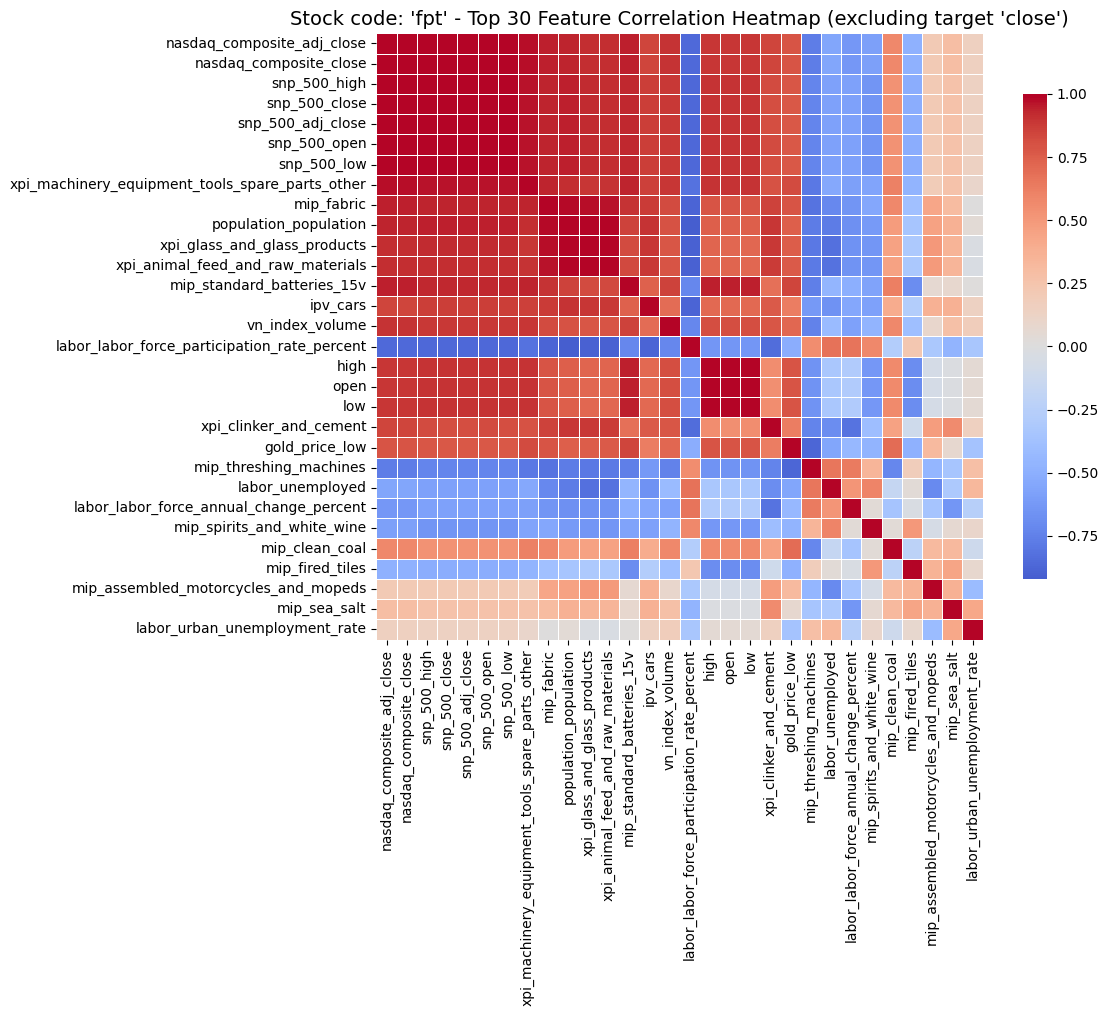

In [41]:
my_feature_selector.plot_feature_correlation_heatmap(
    stock_code=stock_code,
    importane_featrue_list=important_features_list,
    top_corr_threshold=DEFAULT_CORRELATION_THRESHOLD,
)

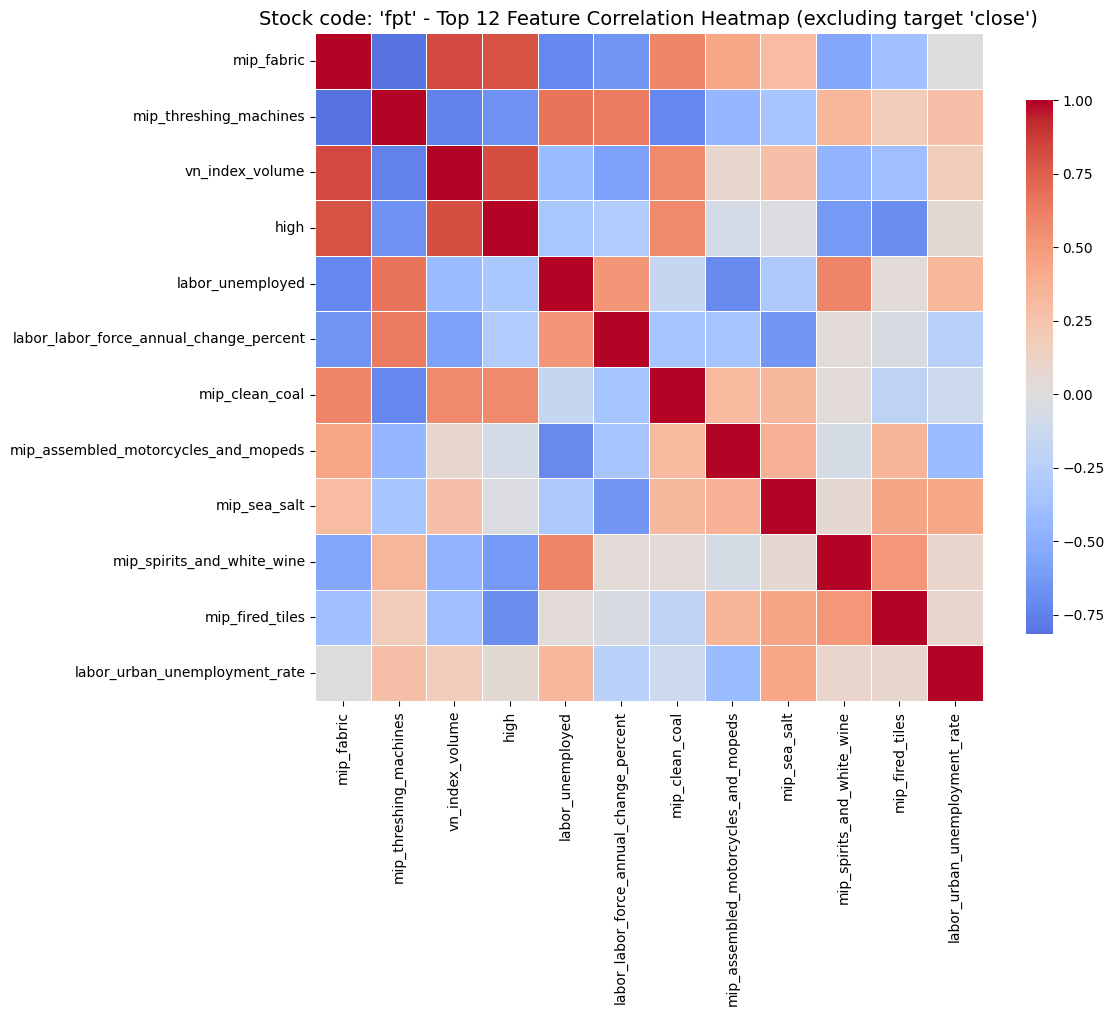

In [42]:
my_feature_selector.plot_feature_correlation_heatmap(
    stock_code=stock_code,
    importane_featrue_list=kept_features,
    top_corr_threshold=DEFAULT_CORRELATION_THRESHOLD,
)

## Feature Selected train dataframe

In [43]:
feature_selected_train

,gdp_gdp_growth,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_coffee,xpi_confectionery_and_cereal_products,xpi_crude_oil,...,is_quarter_end,week_of_month,half_of_year,season,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,7.552055,2888.656452,92.003231,253.595161,16.025534,22.747446,11.056317,747.464516,17.440706,14423.946129,...,0.0,2.0,2.0,1.0,-2.449294e-16,1.000000,0.974928,-0.222521,-0.304921,0.952378
1,7.553425,2898.413871,92.084006,265.067097,16.039604,22.767417,11.066024,750.208710,17.456019,14470.819677,...,0.0,2.0,2.0,1.0,-2.449294e-16,1.000000,0.433884,-0.900969,-0.288482,0.957485
2,7.554795,2908.171290,92.164782,276.539032,16.053674,22.787388,11.075731,752.952903,17.471331,14517.693226,...,0.0,3.0,2.0,1.0,-2.449294e-16,1.000000,-0.433884,-0.900969,-0.271958,0.962309
3,6.860220,805.000000,533.333333,65.833333,144.166667,218.333333,214.166667,86.666667,115.500657,93.333333,...,0.0,4.0,1.0,3.0,1.224647e-16,-1.000000,0.781831,0.623490,0.094537,-0.995521
4,7.558904,2937.443548,92.407108,310.954839,16.095883,22.847303,11.104852,761.185484,17.517268,14658.313871,...,0.0,3.0,2.0,1.0,-2.449294e-16,1.000000,0.000000,1.000000,-0.221922,0.975065
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4135,8.431413,996.774194,388.064516,48.225806,296.774194,214.516129,325.806452,137.903226,104.552365,339.516129,...,0.0,2.0,2.0,3.0,-5.000000e-01,-0.866025,0.000000,1.000000,-0.162807,-0.986658
4136,8.496087,991.935484,385.161290,48.064516,291.935484,216.290323,324.516129,137.258065,104.567677,341.290323,...,0.0,2.0,2.0,3.0,-5.000000e-01,-0.866025,0.781831,0.623490,-0.179767,-0.983709
4137,8.560761,987.096774,382.258065,47.903226,287.096774,218.064516,323.225806,136.612903,104.582989,343.064516,...,0.0,2.0,2.0,3.0,-5.000000e-01,-0.866025,0.974928,-0.222521,-0.196673,-0.980469
4138,8.625435,982.258065,379.354839,47.741935,282.258065,219.838710,321.935484,135.967742,104.598302,344.838710,...,0.0,2.0,2.0,3.0,-5.000000e-01,-0.866025,0.433884,-0.900969,-0.213521,-0.976938
